|                |   |
:----------------|---|
| **Nombre**     |Santiago Escutia Ríos   |
| **Fecha**      | 26/3/2026  |
| **Expediente** |757839   |

In [2]:
import pandas as pd
df= pd.read_csv("Heart Prediction Quantum Dataset.csv")

In [3]:
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [6]:
df.columns

Index(['Age', 'Gender', 'BloodPressure', 'Cholesterol', 'HeartRate',
       'QuantumPatternFeature', 'HeartDisease'],
      dtype='str')

In [7]:
df.describe

<bound method NDFrame.describe of      Age  Gender  BloodPressure  Cholesterol  HeartRate  \
0     68       1            105          191        107   
1     58       0             97          249         89   
2     44       0             93          190         82   
3     72       1             93          183        101   
4     37       0            145          166        103   
..   ...     ...            ...          ...        ...   
495   34       0            126          292        116   
496   41       0            164          248        114   
497   45       1            159          175         75   
498   55       0            107          157        101   
499   55       0            174          249         89   

     QuantumPatternFeature  HeartDisease  
0                 8.362241             1  
1                 9.249002             0  
2                 7.942542             1  
3                 6.495155             1  
4                 7.653900             1  

<Axes: ylabel='Frequency'>

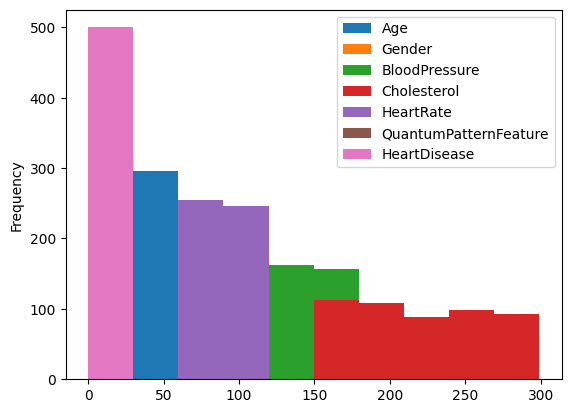

In [8]:
df.plot.hist()

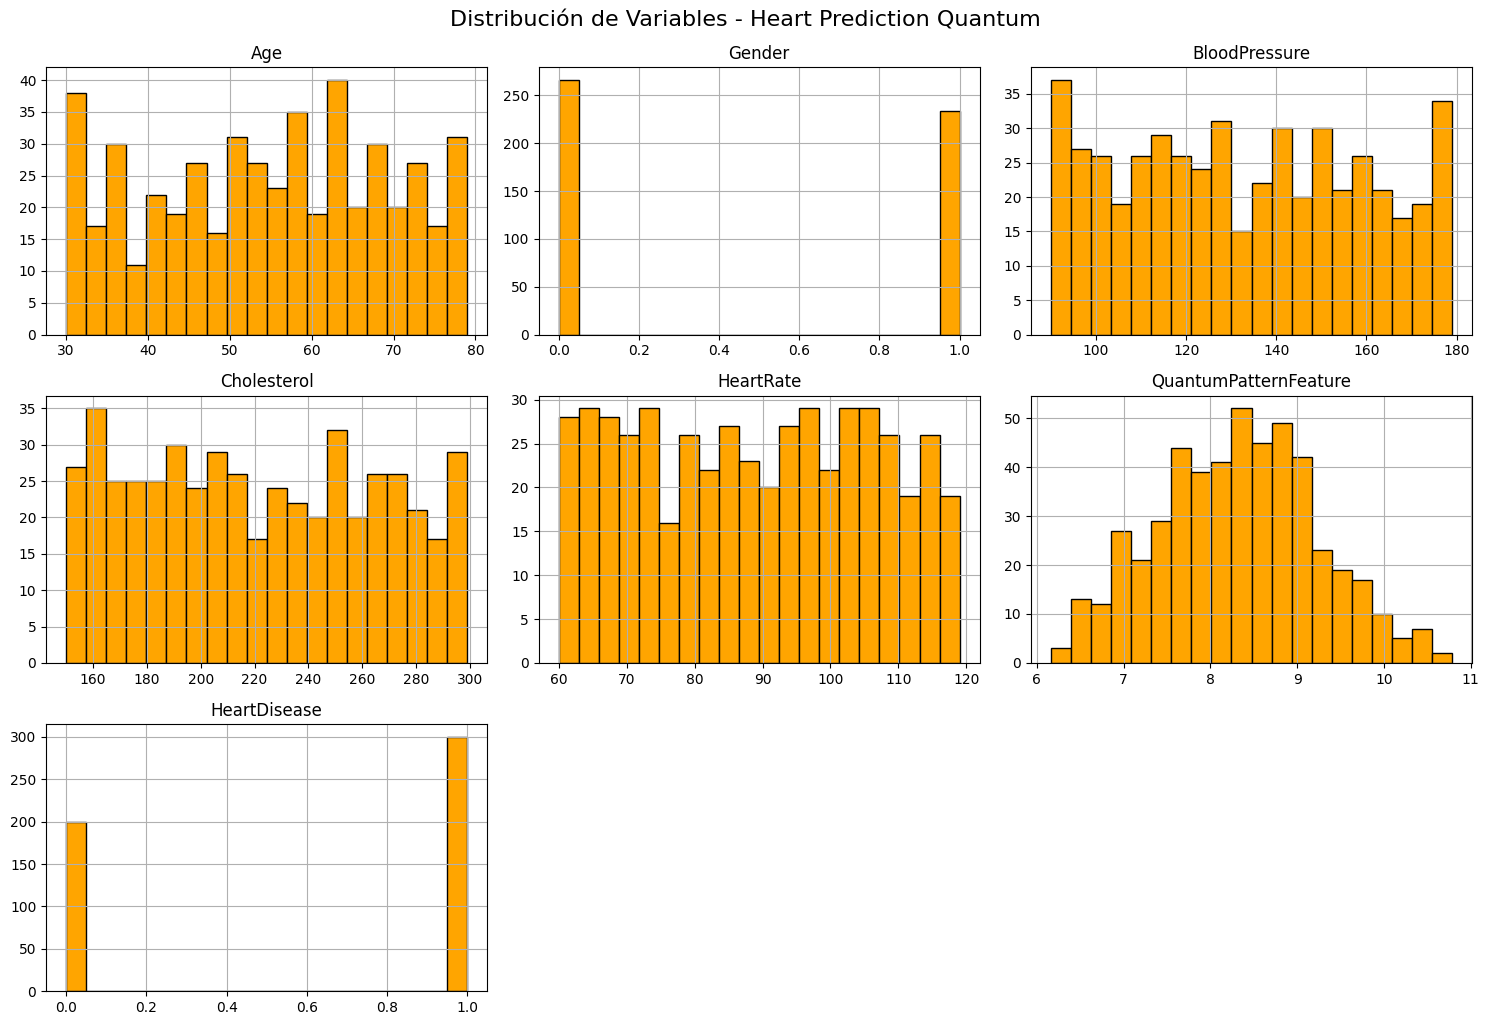

In [14]:
import matplotlib.pyplot as plt

df.hist(bins=20, figsize=(15, 10), color='orange', edgecolor='black')
plt.tight_layout()
plt.suptitle('Distribución de Variables - Heart Prediction Quantum', fontsize=16, y=1.02)
plt.show()

In [15]:
df.columns

Index(['Age', 'Gender', 'BloodPressure', 'Cholesterol', 'HeartRate',
       'QuantumPatternFeature', 'HeartDisease'],
      dtype='str')

In [25]:
import pandas as pd
import optuna
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. CARGAR DATOS
df = pd.read_csv('Heart Prediction Quantum Dataset.csv')

# Excluimos 'HeartDisease' y 'QuantumPatternFeature' como pediste
X = df.drop(['HeartDisease', 'QuantumPatternFeature'], axis=1)
y = df['HeartDisease']

# Reservamos un pequeño set de prueba final para validación ciega
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. FUNCIÓN OBJETIVO CON K-FOLDS
def objective(trial):
    # Sugerir hiperparámetros
    n_layers = trial.suggest_int('n_layers', 1, 2)
    hidden_layers = tuple([trial.suggest_int(f'units_l{i}', 16, 64) for i in range(n_layers)])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    # Definir el Pipeline (Escalado + MLP)
    # Importante: El escalador va dentro para que se ajuste en cada fold por separado
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            learning_rate_init=lr,
            max_iter=1000,
            random_state=42
        ))
    ])
    
    # Configurar K-Fold (usaremos 5 folds)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calcular el Accuracy promedio usando validación cruzada
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
    
    return scores.mean()

# 3. EJECUTAR LA OPTIMIZACIÓN
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

# 4. RESULTADOS FINALES
print(f"--- RESULTADOS ---")
print(f"Mejor Accuracy promedio (CV): {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")

# (Opcional) Evaluar el mejor modelo en el Test Set final
best_params = study.best_params
layers = tuple([best_params[f'units_l{i}'] for i in range(best_params['n_layers'])])

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=layers,
        learning_rate_init=best_params['lr'],
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)
test_score = final_model.score(X_test, y_test)
print(f"Accuracy final en Test Set (no visto): {test_score:.4f}")

[I 2026-03-26 17:39:50,881] A new study created in memory with name: no-name-6299f300-35bb-4d27-b404-8db14ce59edc
[I 2026-03-26 17:39:52,443] Trial 0 finished with value: 0.765 and parameters: {'n_layers': 1, 'units_l0': 48, 'lr': 0.00037168216740003526}. Best is trial 0 with value: 0.765.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Opti

--- RESULTADOS ---
Mejor Accuracy promedio (CV): 0.7825
Mejores parámetros: {'n_layers': 2, 'units_l0': 35, 'units_l1': 38, 'lr': 0.00010072377801970666}
Accuracy final en Test Set (no visto): 0.8100


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV

# 1. CARGA DE DATOS Y DEFINICIÓN DE X/y
# Asegúrate de que el nombre del archivo coincida con el tuyo
df = pd.read_csv("Heart Prediction Quantum Dataset.csv")

# Creamos X (características) e y (objetivo)
# Eliminamos columnas innecesarias como Patient ID si existen
X = df.drop(columns=['Heart Attack Risk']) 
y = df['Heart Attack Risk']

# Convertimos variables categóricas a números (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 2. DEFINICIÓN DEL MODELO (PIPELINE)
# Usamos StandardScaler porque el MLP es muy sensible a la escala de los datos
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=500, early_stopping=True, random_state=42))
])

# 3. ESPACIO DE BÚSQUEDA (3 Capas con tus rangos)
# Capa 1: [2,6], Capa 2: [5,15], Capa 3: [3,16]
search_space = {
    'mlp__hidden_layer_sizes': [
        (i, j, k) 
        for i in range(2, 7)    # Rango [2,6]
        for j in range(5, 16)   # Rango [5,15]
        for k in range(3, 17)   # Rango [3,16]
    ]
}

# 4. OPTIMIZACIÓN BAYESIANA CON ROC-AUC
opt = BayesSearchCV(
    estimator=mlp_pipeline,
    search_spaces=search_space,
    n_iter=15, # Número de combinaciones a probar
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', # Métrica solicitada
    n_jobs=-1,
    random_state=42
)

print("Iniciando optimización bayesiana de 3 capas...")
opt.fit(X, y)

# 5. RESULTADOS FINALES
print("-" * 30)
print(f"Mejor ROC-AUC obtenido: {opt.best_score_:.4f}")
print(f"Mejor combinación de capas: {opt.best_params_['mlp__hidden_layer_sizes']}")

KeyError: "['Heart Attack Risk'] not found in axis"